# 05 — Evaluation and comparison

In this notebook, I compare the outputs from my three segmentation approaches: Otsu thresholding, Random Forest, and the patch-based CNN. I use the saved results from the earlier notebooks and evaluate them against the Weka reference masks on the same held-out test images so that the comparison is fair.

My workflow in this notebook is:

1. load the image inventory and the saved results from Notebooks 2–4  
2. standardise the outputs into one comparison table  
3. compare porosity predictions and segmentation metrics across methods  
4. visualise the lowest- and highest-porosity test examples  
5. summarise which method performed best overall  

Useful background links:  
- AI algorithms: https://cpomucl.github.io/GEOL0069-AI4EO/Chapter_1_AI_Algorithms.html  
- Full-image rollout: https://cpomucl.github.io/GEOL0069-AI4EO/Chapter_1_rollout_3.html  




In [2]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path

REPO_ROOT = Path("/content/drive/MyDrive/GEOL0069-sem-segmentation-project")

DATA_DIR = REPO_ROOT / "data"
CROPPED_DIR = DATA_DIR / "cropped"
MASK_DIR = DATA_DIR / "masks_weka"
META_DIR = DATA_DIR / "metadata"

RESULTS_DIR = REPO_ROOT / "results"
FIG_DIR = RESULTS_DIR / "comparison_figures"

INVENTORY_PATH = META_DIR / "image_inventory.csv"

OTSU_RESULTS_PATH = RESULTS_DIR / "otsu_results.csv"
RF_TEST_RESULTS_PATH = RESULTS_DIR / "rf_test_results.csv"
CNN_TEST_RESULTS_PATH = RESULTS_DIR / "cnn_test_results.csv"

OTSU_MASK_DIR = RESULTS_DIR / "otsu_masks"
RF_MASK_DIR = RESULTS_DIR / "rf_masks"
CNN_MASK_DIR = RESULTS_DIR / "cnn_masks"

FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("Inventory file:", INVENTORY_PATH)
print("Results folder:", RESULTS_DIR)
print("Figure output folder:", FIG_DIR)

for p in [
    CROPPED_DIR, MASK_DIR, META_DIR, RESULTS_DIR,
    OTSU_MASK_DIR, RF_MASK_DIR, CNN_MASK_DIR
]:
    print(f"{p.name:>20} exists -> {p.exists()}")


Repository root: /content/drive/MyDrive/GEOL0069-sem-segmentation-project
Inventory file: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/data/metadata/image_inventory.csv
Results folder: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results
Figure output folder: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/comparison_figures
             cropped exists -> True
          masks_weka exists -> True
            metadata exists -> True
             results exists -> True
          otsu_masks exists -> True
            rf_masks exists -> True
           cnn_masks exists -> True


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [5]:
def read_gray(path):
    return np.array(Image.open(path).convert("L"))

def read_weka_mask(path):
    """
    Weka masks are interpreted with dark pixels as pores.
    """
    arr = np.array(Image.open(path).convert("L"))
    return (arr < 128).astype(np.uint8)

def read_saved_pred_mask(path):
    """
    Saved prediction masks from my notebooks were written as 0/255 images,
    so pore pixels are any non-zero value.
    """
    arr = np.array(Image.open(path).convert("L"))
    return (arr > 0).astype(np.uint8)

def porosity_percent(mask):
    return float(mask.mean() * 100.0)

def first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def assign_default_split(df):
    """
    Recreates the same image-level split if 'split' is missing.
    For each magnification group of 4 images:
    first 2 -> train, third -> val, fourth -> test
    """
    df = df.copy()

    if "split" in df.columns:
        split_ok = df["split"].fillna("").astype(str).str.strip()
        if (split_ok != "").all():
            return df

    mag_col = first_existing(df.columns, ["actual_magnification", "magnification"])
    id_col = first_existing(df.columns, ["image_id"])

    df["split"] = ""

    for mag, sub in df.sort_values([mag_col, id_col]).groupby(mag_col):
        idx = list(sub.index)
        if len(idx) >= 4:
            df.loc[idx[:2], "split"] = "train"
            df.loc[idx[2], "split"] = "val"
            df.loc[idx[3:], "split"] = "test"
        elif len(idx) == 3:
            df.loc[idx[:2], "split"] = "train"
            df.loc[idx[2], "split"] = "test"
        elif len(idx) == 2:
            df.loc[idx[0], "split"] = "train"
            df.loc[idx[1], "split"] = "test"
        elif len(idx) == 1:
            df.loc[idx[0], "split"] = "test"

    return df

def standardise_results(df, method_name, pred_col):
    df = df.copy()

    weka_col = first_existing(df.columns, ["weka_porosity", "porosity_weka"])
    mag_col = first_existing(df.columns, ["actual_magnification", "magnification"])

    df = df.rename(columns={
        weka_col: "weka_porosity",
        mag_col: "actual_magnification",
        pred_col: "predicted_porosity"
    })

    for col in ["iou", "precision", "recall", "f1", "abs_error", "pred_mask_file"]:
        if col not in df.columns:
            df[col] = np.nan

    keep_cols = [
        "image_id",
        "actual_magnification",
        "weka_porosity",
        "predicted_porosity",
        "iou",
        "precision",
        "recall",
        "f1",
        "abs_error",
        "pred_mask_file"
    ]

    out = df[keep_cols].copy()
    out["method"] = method_name
    return out

def get_pred_mask(result_df, sample_id, mask_dir):
    row = result_df[result_df["image_id"] == sample_id]
    if row.empty:
        return None

    mask_name = row.iloc[0]["pred_mask_file"]
    if pd.isna(mask_name) or str(mask_name).strip() == "":
        return None

    mask_path = mask_dir / str(mask_name)
    if not mask_path.exists():
        return None

    return read_saved_pred_mask(mask_path)

def add_identity_line(ax, values_x, values_y):
    all_vals = list(values_x) + list(values_y)
    lo = min(all_vals)
    hi = max(all_vals)
    ax.plot([lo, hi], [lo, hi], "--", linewidth=1)

def method_color(method):
    colors = {
        "Otsu": "#999999",
        "Random Forest": "#1f77b4",
        "CNN": "#d62728"
    }
    return colors.get(method, "black")


In [7]:
inventory = pd.read_csv(INVENTORY_PATH)
inventory = assign_default_split(inventory)

if "porosity_weka" in inventory.columns:
    inventory["porosity_weka"] = pd.to_numeric(inventory["porosity_weka"], errors="coerce")

display(
    inventory[
        ["image_id", "actual_magnification", "cropped_file", "weka_mask", "porosity_weka", "split"]
    ]
)

print("Total images:", len(inventory))
print("\nSplit counts:")
print(inventory["split"].value_counts(dropna=False))


,image_id,actual_magnification,cropped_file,weka_mask,porosity_weka,split
0,13064_05_17A_400X-8-83,400,13064_05_17A_400X-8-83cropped.tif,13064_05_17A_400X-8-83mask.tif,1.000000,train
1,13074_00_18A_400X-9-10,400,13074_00_18A_400X-9-10cropped.tif,13074_00_18A_400X-9-10mask.tif,0.070000,train
2,13123_00_21A_400X-9-59,400,13123_00_21A_400X-9-59cropped.tif,13123_00_21A_400X-9-59mask.tif,2.268000,val
3,R2_10,400,R2_10cropped.tif,R2_10mask.tif,0.000477,test
4,13064_05_17B_1000X-8-83,1000,13064_05_17B_1000X-8-83cropped.tif,13064_05_17B_1000X-8-83mask.tif,1.987000,train
5,13087_50_19B_1000X-9-23,1000,13087_50_19B_1000X-9-23cropped.tif,13087_50_19B_1000X-9-23mask.tif,1.830000,train
6,13103_60_20B_1000X-9-39,1000,13103_60_20B_1000X-9-39cropped.tif,13103_60_20B_1000X-9-39mask.tif,0.445000,val
7,13123_00_21B_1000X-9-59,1000,13123_00_21B_1000X-9-59cropped.tif,13123_00_21B_1000X-9-59mask.tif,1.500000,test
8,13064_05_17C_2000X-8-83,2000,13064_05_17C_2000X-8-83cropped.tif,13064_05_17C_2000X-8-83mask.tif,2.078000,train
9,13087_50_19C_2000X-9-23,2000,13087_50_19C_2000X-9-23cropped.tif,13087_50_19C_2000X-9-23mask.tif,3.567000,train


Total images: 16

Split counts:
split
train    8
val      4
test     4
Name: count, dtype: int64


In [8]:
test_inventory = inventory[inventory["split"] == "test"].copy()
test_ids = test_inventory["image_id"].tolist()

print("Held-out test images:")
for image_id in test_ids:
    print("-", image_id)


Held-out test images:
- R2_10
- 13123_00_21B_1000X-9-59
- B3_2
- 13162_65_24D_3000X-10-8


In [9]:
otsu_raw = pd.read_csv(OTSU_RESULTS_PATH)
rf_raw = pd.read_csv(RF_TEST_RESULTS_PATH)
cnn_raw = pd.read_csv(CNN_TEST_RESULTS_PATH)

otsu = standardise_results(otsu_raw, "Otsu", "otsu_porosity")
rf = standardise_results(rf_raw, "Random Forest", "rf_porosity")
cnn = standardise_results(cnn_raw, "CNN", "cnn_porosity")

comparison_long = pd.concat([
    otsu[otsu["image_id"].isin(test_ids)].copy(),
    rf[rf["image_id"].isin(test_ids)].copy(),
    cnn[cnn["image_id"].isin(test_ids)].copy()
], ignore_index=True)

comparison_long["abs_error"] = (
    comparison_long["predicted_porosity"] - comparison_long["weka_porosity"]
).abs()

comparison_long = comparison_long.sort_values(["image_id", "method"]).reset_index(drop=True)

comparison_long.to_csv(RESULTS_DIR / "comparison_test_long.csv", index=False)

display(comparison_long.round(4))
print("Saved:", RESULTS_DIR / "comparison_test_long.csv")


,image_id,actual_magnification,weka_porosity,predicted_porosity,iou,precision,recall,f1,abs_error,pred_mask_file,method
0,13123_00_21B_1000X-9-59,1000,1.5000,5.6257,0.2649,0.2653,0.9947,0.4189,4.1257,13123_00_21B_1000X-9-59_cnn_mask.png,CNN
1,13123_00_21B_1000X-9-59,1000,1.5000,43.2777,0.0347,0.0347,1.0000,0.0670,41.7777,13123_00_21B_1000X-9-59_otsu_mask.png,Otsu
2,13123_00_21B_1000X-9-59,1000,1.5000,3.7343,0.3980,0.3991,0.9934,0.5694,2.2343,13123_00_21B_1000X-9-59_rf_mask.png,Random Forest
3,13162_65_24D_3000X-10-8,3000,3.4080,6.2315,0.4645,0.4906,0.8971,0.6343,2.8235,13162_65_24D_3000X-10-8_cnn_mask.png,CNN
4,13162_65_24D_3000X-10-8,3000,3.4080,36.1135,0.0944,0.0944,0.9999,0.1724,32.7055,13162_65_24D_3000X-10-8_otsu_mask.png,Otsu
5,13162_65_24D_3000X-10-8,3000,3.4080,5.8934,0.4809,0.5125,0.8864,0.6495,2.4854,13162_65_24D_3000X-10-8_rf_mask.png,Random Forest
6,B3_2,2000,0.9130,0.0000,0.0000,0.0000,0.0000,0.0000,0.9130,B3_2_cnn_mask.png,CNN
7,B3_2,2000,0.9130,32.2026,0.0283,0.0283,1.0000,0.0551,31.2896,B3_2_otsu_mask.png,Otsu
8,B3_2,2000,0.9130,0.0008,0.0008,1.0000,0.0008,0.0017,0.9122,B3_2_rf_mask.png,Random Forest
9,R2_10,400,0.0005,0.0000,0.0000,0.0000,0.0000,0.0000,0.0005,R2_10_cnn_mask.png,CNN


Saved: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/comparison_test_long.csv


In [10]:
method_order = ["Otsu", "Random Forest", "CNN"]

method_summary = (
    comparison_long
    .groupby("method", as_index=False)
    .agg(
        n_images=("image_id", "count"),
        mean_weka_porosity=("weka_porosity", "mean"),
        mean_predicted_porosity=("predicted_porosity", "mean"),
        mean_abs_error=("abs_error", "mean"),
        mean_iou=("iou", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean")
    )
)

method_summary["method"] = pd.Categorical(
    method_summary["method"], categories=method_order, ordered=True
)
method_summary = method_summary.sort_values("method").reset_index(drop=True)

method_summary.to_csv(RESULTS_DIR / "comparison_method_summary.csv", index=False)

display(method_summary.round(4))
print("Saved:", RESULTS_DIR / "comparison_method_summary.csv")


,method,n_images,mean_weka_porosity,mean_predicted_porosity,mean_abs_error,mean_iou,mean_precision,mean_recall,mean_f1
0,Otsu,4,1.4554,36.6023,35.1470,0.0393,0.0393,1.0000,0.0736
1,Random Forest,4,1.4554,2.4071,1.4081,0.2200,0.4779,0.4702,0.3052
2,CNN,4,1.4554,2.9643,1.9657,0.1823,0.1890,0.4730,0.2633


Saved: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/comparison_method_summary.csv


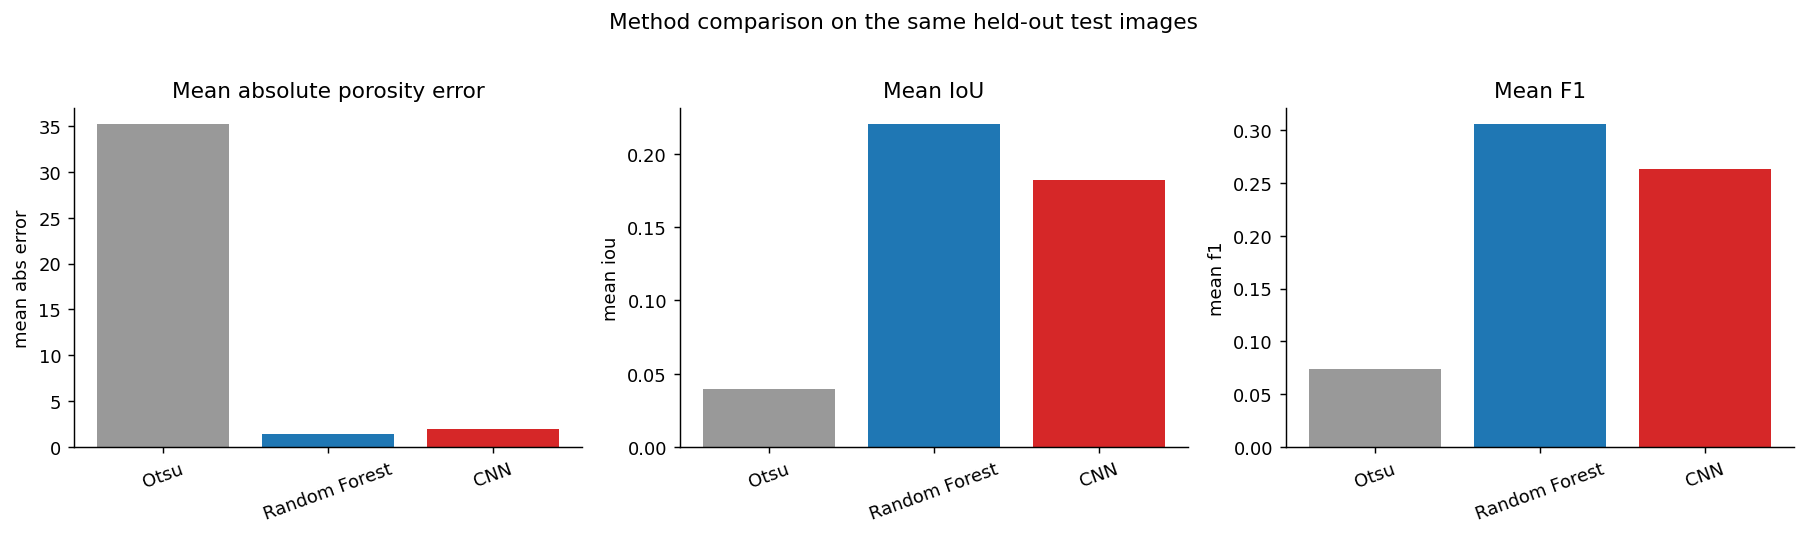

Saved figure: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/comparison_figures/comparison_method_summary.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics_to_plot = [
    ("mean_abs_error", "Mean absolute porosity error"),
    ("mean_iou", "Mean IoU"),
    ("mean_f1", "Mean F1")
]

for ax, (metric, title) in zip(axes, metrics_to_plot):
    vals = method_summary[metric].values
    labels = method_summary["method"].tolist()
    colors = [method_color(m) for m in labels]

    ax.bar(labels, vals, color=colors)
    ax.set_title(title)
    ax.set_ylabel(metric.replace("_", " "))
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Method comparison on the same held-out test images", y=1.02)
plt.tight_layout()

fig_path = FIG_DIR / "comparison_method_summary.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## Per-image comparison

In the next cell, I compare the methods image by image. This is useful because the averages alone do not show how differently the models behave on very low-porosity and higher-porosity samples.


In [12]:
porosity_wide = (
    comparison_long
    .pivot_table(
        index=["image_id", "actual_magnification", "weka_porosity"],
        columns="method",
        values="predicted_porosity"
    )
    .reset_index()
)

porosity_wide.columns.name = None
porosity_wide = porosity_wide.sort_values("weka_porosity").reset_index(drop=True)

f1_wide = (
    comparison_long
    .pivot_table(
        index="image_id",
        columns="method",
        values="f1"
    )
    .reset_index()
)

f1_wide.columns.name = None

porosity_wide.to_csv(RESULTS_DIR / "comparison_porosity_wide.csv", index=False)
f1_wide.to_csv(RESULTS_DIR / "comparison_f1_wide.csv", index=False)

display(porosity_wide.round(4))
display(f1_wide.round(4))

print("Saved:", RESULTS_DIR / "comparison_porosity_wide.csv")
print("Saved:", RESULTS_DIR / "comparison_f1_wide.csv")


,image_id,actual_magnification,weka_porosity,CNN,Otsu,Random Forest
0,R2_10,400,0.0005,0.0000,34.8156,0.0000
1,B3_2,2000,0.9130,0.0000,32.2026,0.0008
2,13123_00_21B_1000X-9-59,1000,1.5000,5.6257,43.2777,3.7343
3,13162_65_24D_3000X-10-8,3000,3.4080,6.2315,36.1135,5.8934


,image_id,CNN,Otsu,Random Forest
0,13123_00_21B_1000X-9-59,0.4189,0.0670,0.5694
1,13162_65_24D_3000X-10-8,0.6343,0.1724,0.6495
2,B3_2,0.0000,0.0551,0.0017
3,R2_10,0.0000,0.0000,0.0000


Saved: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/comparison_porosity_wide.csv
Saved: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/comparison_f1_wide.csv


/tmp/ipykernel_7635/1673110260.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(image_order, rotation=30, ha="right")


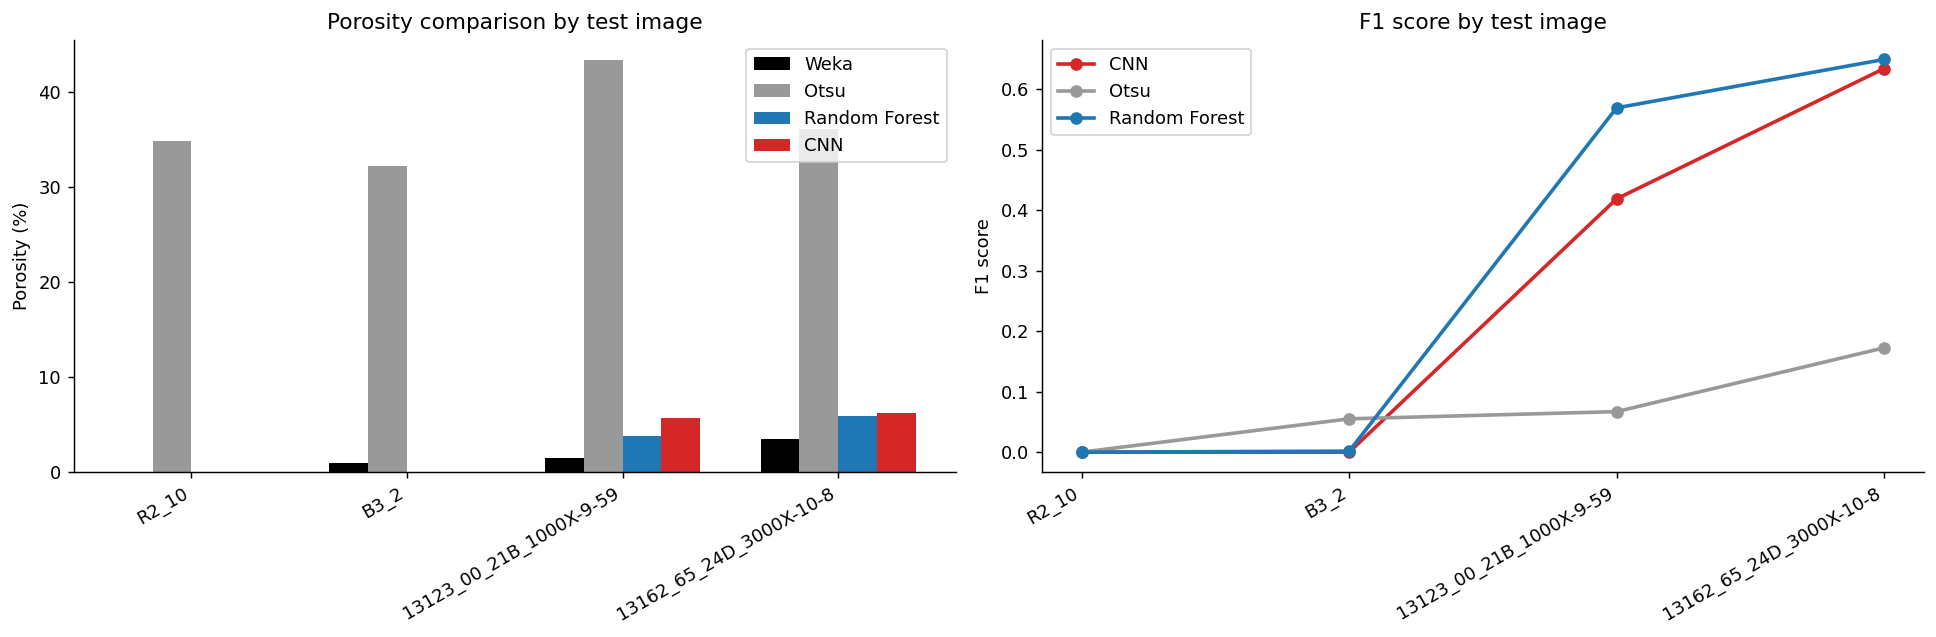

Saved figure: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/comparison_figures/comparison_by_image.png


In [13]:
image_order = porosity_wide["image_id"].tolist()
x = np.arange(len(image_order))
width = 0.18

weka_vals = porosity_wide["weka_porosity"].values
otsu_vals = porosity_wide["Otsu"].values if "Otsu" in porosity_wide.columns else np.full(len(image_order), np.nan)
rf_vals = porosity_wide["Random Forest"].values if "Random Forest" in porosity_wide.columns else np.full(len(image_order), np.nan)
cnn_vals = porosity_wide["CNN"].values if "CNN" in porosity_wide.columns else np.full(len(image_order), np.nan)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(x - 1.5*width, weka_vals, width, label="Weka", color="black")
axes[0].bar(x - 0.5*width, otsu_vals, width, label="Otsu", color=method_color("Otsu"))
axes[0].bar(x + 0.5*width, rf_vals, width, label="Random Forest", color=method_color("Random Forest"))
axes[0].bar(x + 1.5*width, cnn_vals, width, label="CNN", color=method_color("CNN"))
axes[0].set_xticks(x)
axes[0].set_xticklabels(image_order, rotation=30, ha="right")
axes[0].set_ylabel("Porosity (%)")
axes[0].set_title("Porosity comparison by test image")
axes[0].legend()

f1_plot = comparison_long.pivot_table(index="image_id", columns="method", values="f1").reindex(image_order)
for method in f1_plot.columns:
    axes[1].plot(
        image_order,
        f1_plot[method].values,
        marker="o",
        linewidth=2,
        label=method,
        color=method_color(method)
    )

axes[1].set_ylabel("F1 score")
axes[1].set_title("F1 score by test image")
axes[1].set_xticklabels(image_order, rotation=30, ha="right")
axes[1].legend()

plt.tight_layout()

fig_path = FIG_DIR / "comparison_by_image.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


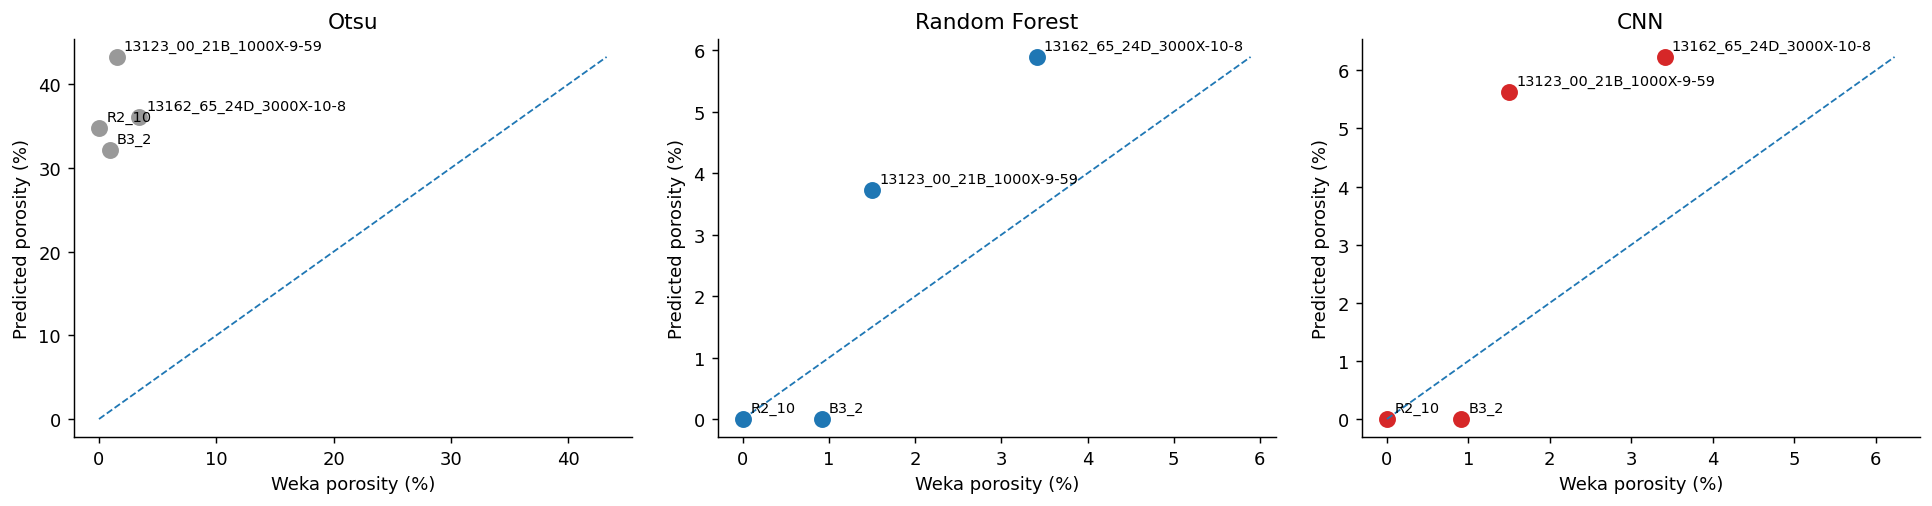

Saved figure: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/comparison_figures/comparison_scatter_porosity.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, method in zip(axes, ["Otsu", "Random Forest", "CNN"]):
    sub = comparison_long[comparison_long["method"] == method].copy()

    ax.scatter(
        sub["weka_porosity"],
        sub["predicted_porosity"],
        s=70,
        color=method_color(method)
    )

    for _, row in sub.iterrows():
        ax.annotate(
            row["image_id"],
            (row["weka_porosity"], row["predicted_porosity"]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points"
        )

    add_identity_line(ax, sub["weka_porosity"].values, sub["predicted_porosity"].values)
    ax.set_title(method)
    ax.set_xlabel("Weka porosity (%)")
    ax.set_ylabel("Predicted porosity (%)")

plt.tight_layout()

fig_path = FIG_DIR / "comparison_scatter_porosity.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## Full test-set rollout


Number of test images: 4


,image_id,actual_magnification,weka_porosity,otsu_porosity,rf_porosity,cnn_porosity,otsu_iou,rf_iou,cnn_iou,otsu_f1,rf_f1,cnn_f1
0,R2_10,400,0.000477,34.815557,0.000000,0.000000,0.000014,0.000000,0.000000,0.000027,0.000000,0.000000
1,B3_2,2000,0.913000,32.202580,0.000757,0.000000,0.028338,0.000829,0.000000,0.055115,0.001658,0.000000
2,13123_00_21B_1000X-9-59,1000,1.500000,43.277682,3.734338,5.625722,0.034666,0.398048,0.264907,0.067009,0.569434,0.418856
3,13162_65_24D_3000X-10-8,3000,3.408000,36.113480,5.893351,6.231470,0.094359,0.480947,0.464479,0.172446,0.649513,0.634327


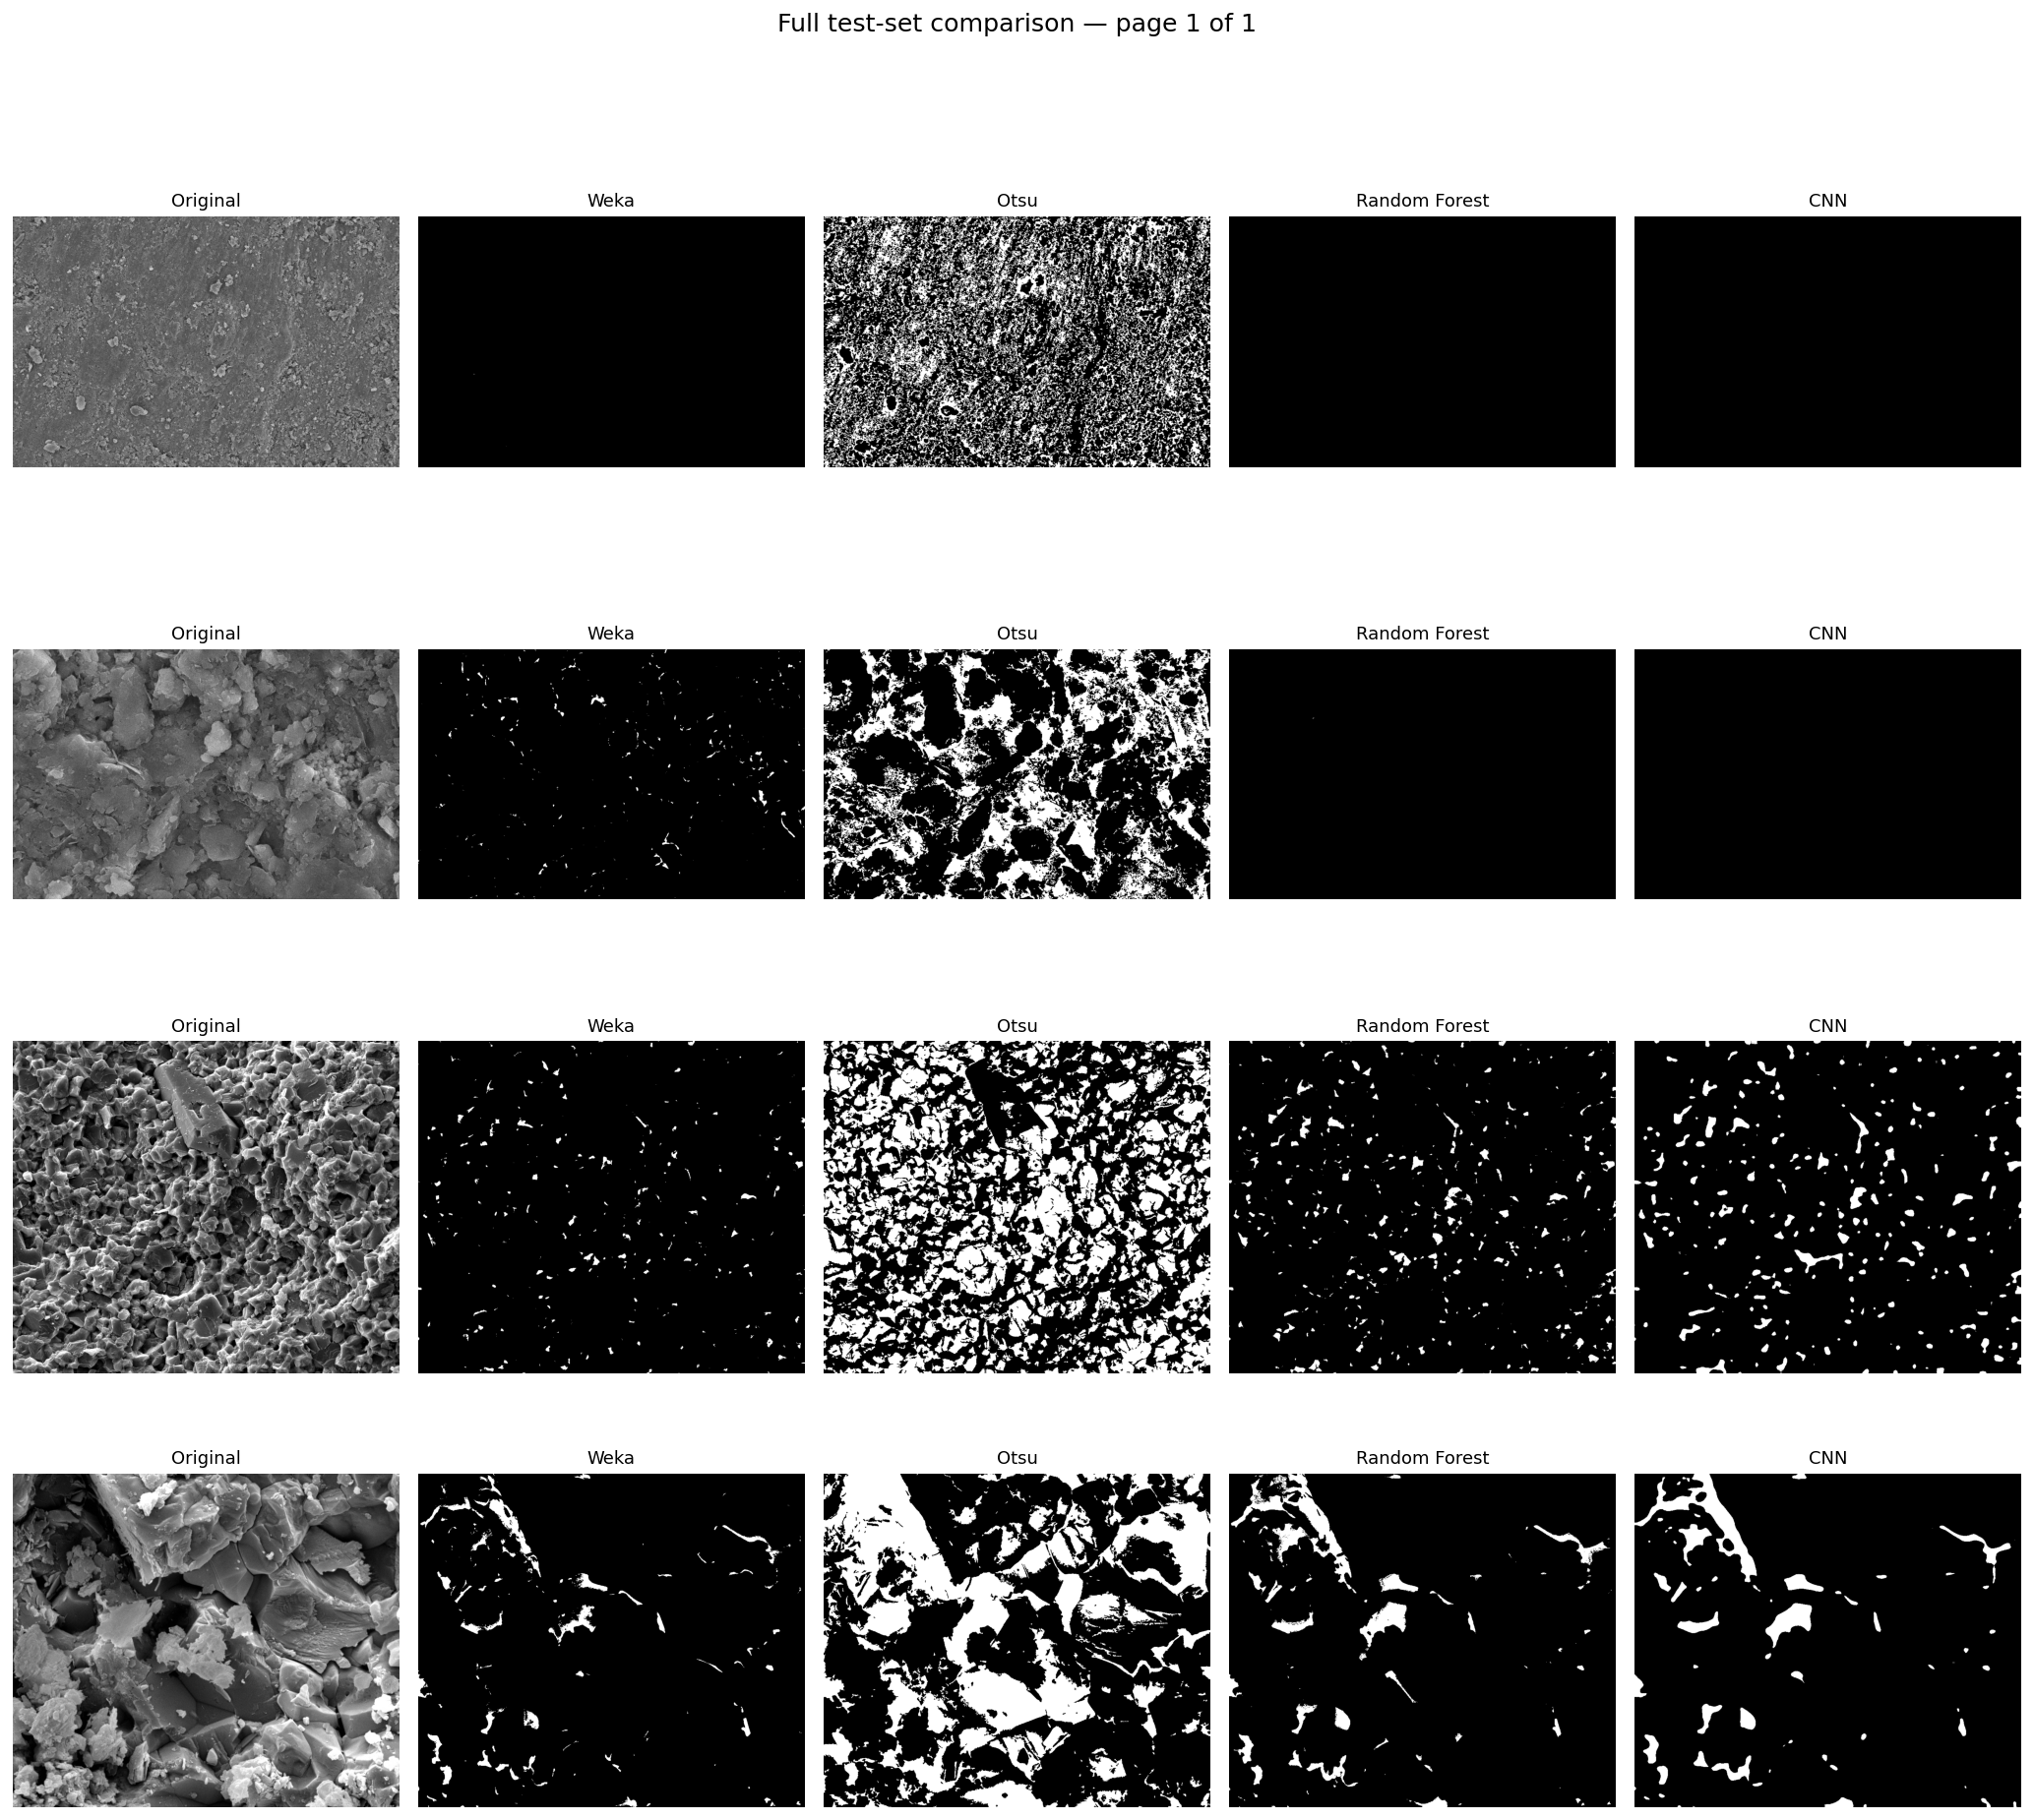

Saved rollout table to: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/comparison_full_rollout_table.csv
Saved rollout figures to: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/comparison_figures


In [16]:
# Full rollout of all test images: Original, Weka, Otsu, Random Forest, CNN

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Helper functions
# ----------------------------
def safe_result_value(df, sample_id, col):
    if df is None or df.empty or col not in df.columns:
        return np.nan
    row = df[df["image_id"] == sample_id]
    if row.empty:
        return np.nan
    return row.iloc[0][col]

def safe_mask(df, sample_id, mask_dir):
    if df is None or df.empty:
        return None
    row = df[df["image_id"] == sample_id]
    if row.empty or "pred_mask_file" not in row.columns:
        return None
    name = row.iloc[0]["pred_mask_file"]
    if pd.isna(name) or str(name).strip() == "":
        return None
    path = mask_dir / str(name)
    if not path.exists():
        return None
    return read_saved_pred_mask(path)

# ----------------------------
# Select test images
# ----------------------------
inventory_view = inventory.copy()

if "split" in inventory_view.columns:
    test_df = inventory_view[
        inventory_view["split"].astype(str).str.strip().str.lower() == "test"
    ].copy()
else:
    test_df = inventory_view.copy()

test_df["porosity_weka"] = pd.to_numeric(test_df["porosity_weka"], errors="coerce")
test_df = test_df.dropna(subset=["porosity_weka"]).sort_values("porosity_weka").reset_index(drop=True)

if test_df.empty:
    print("No test images found for rollout.")
else:
    test_ids = test_df["image_id"].tolist()
    print(f"Number of test images: {len(test_ids)}")

    # ----------------------------
    # Metrics summary table
    # ----------------------------
    rollout_rows = []
    for sample_id in test_ids:
        rollout_rows.append({
            "image_id": sample_id,
            "actual_magnification": (
                safe_result_value(otsu, sample_id, "actual_magnification")
                if "actual_magnification" in otsu.columns
                else safe_result_value(rf, sample_id, "actual_magnification")
            ),
            "weka_porosity": test_df.loc[test_df["image_id"] == sample_id, "porosity_weka"].iloc[0],
            "otsu_porosity": safe_result_value(otsu, sample_id, "predicted_porosity"),
            "rf_porosity": safe_result_value(rf, sample_id, "predicted_porosity"),
            "cnn_porosity": safe_result_value(cnn, sample_id, "predicted_porosity"),
            "otsu_iou": safe_result_value(otsu, sample_id, "iou"),
            "rf_iou": safe_result_value(rf, sample_id, "iou"),
            "cnn_iou": safe_result_value(cnn, sample_id, "iou"),
            "otsu_f1": safe_result_value(otsu, sample_id, "f1"),
            "rf_f1": safe_result_value(rf, sample_id, "f1"),
            "cnn_f1": safe_result_value(cnn, sample_id, "f1"),
        })

    rollout_table = pd.DataFrame(rollout_rows)
    rollout_csv_path = RESULTS_DIR / "comparison_full_rollout_table.csv"
    rollout_table.to_csv(rollout_csv_path, index=False)

    display(rollout_table)

    # ----------------------------
    # Visual rollout in pages
    # ----------------------------
    n_per_page = 4
    n_pages = math.ceil(len(test_ids) / n_per_page)

    for page in range(n_pages):
        batch_ids = test_ids[page * n_per_page : (page + 1) * n_per_page]
        n_rows = len(batch_ids)

        fig, axes = plt.subplots(n_rows, 5, figsize=(16, 3.6 * n_rows))
        if n_rows == 1:
            axes = np.expand_dims(axes, axis=0)

        for r, sample_id in enumerate(batch_ids):
            row = test_df[test_df["image_id"] == sample_id].iloc[0]

            cropped_name = str(row.get("cropped_file", "")).strip()
            raw_name = str(row.get("raw_file", "")).strip()

            image_path = None
            if cropped_name and (CROPPED_DIR / cropped_name).exists():
                image_path = CROPPED_DIR / cropped_name
            elif raw_name and (RAW_DIR / raw_name).exists():
                image_path = RAW_DIR / raw_name

            img = read_gray(image_path) if image_path is not None else None

            gt = None
            weka_name = str(row.get("weka_mask", "")).strip()
            if weka_name:
                gt_path = MASK_DIR / weka_name
                if gt_path.exists():
                    gt = read_weka_mask(gt_path)

            otsu_mask = safe_mask(otsu, sample_id, OTSU_MASK_DIR)
            rf_mask   = safe_mask(rf,   sample_id, RF_MASK_DIR)
            cnn_mask  = safe_mask(cnn,  sample_id, CNN_MASK_DIR)

            panels = [
                (img, "Original"),
                (gt, "Weka"),
                (otsu_mask, "Otsu"),
                (rf_mask, "Random Forest"),
                (cnn_mask, "CNN"),
            ]

            for c, (panel_img, title) in enumerate(panels):
                ax = axes[r, c]
                if panel_img is None:
                    ax.imshow(np.zeros((32, 32)), cmap="gray", vmin=0, vmax=1)
                    ax.set_title(f"{title}\nnot available", fontsize=10)
                else:
                    ax.imshow(panel_img, cmap="gray")
                    ax.set_title(title, fontsize=10)
                ax.axis("off")

            wp = row["porosity_weka"]
            op = safe_result_value(otsu, sample_id, "predicted_porosity")
            rp = safe_result_value(rf, sample_id, "predicted_porosity")
            cp = safe_result_value(cnn, sample_id, "predicted_porosity")

            axes[r, 0].set_ylabel(
                f"{sample_id}\n"
                f"Weka: {wp:.2f}%\n"
                f"Otsu: {op:.2f}% | RF: {rp:.2f}% | CNN: {cp:.2f}%",
                rotation=0,
                ha="right",
                va="center",
                labelpad=55,
                fontsize=9
            )

        plt.suptitle(f"Full test-set comparison — page {page + 1} of {n_pages}", y=1.02, fontsize=14)
        plt.tight_layout()

        save_path = FIG_DIR / f"comparison_full_rollout_page_{page + 1}.png"
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.show()

    print(f"Saved rollout table to: {rollout_csv_path}")
    print(f"Saved rollout figures to: {FIG_DIR}")


## Discussion

In this notebook, I compared a classical unsupervised segmentation method (Otsu thresholding) with two supervised machine-learning approaches (Random Forest and a patch-based CNN), using the Trainable Weka Segmentation masks as the reference for pore-space classification. This addresses the main aim of the project: to test whether simple machine-learning models trained from Weka-derived labels could reproduce pore segmentation in SEM/BSE images more reliably than a standard thresholding method, and to examine how those segmentation choices affect the derived porosity values.

The results show a clear difference between the methods. Otsu thresholding performed worst overall, consistently overestimating porosity and giving very poor overlap with the Weka masks. This indicates that grey-value thresholding alone is not sufficient for these images, where pore space is subtle and can overlap visually with other dark features. In contrast, both supervised methods produced more realistic segmentations and porosity estimates. The Random Forest gave the strongest overall agreement with the Weka masks and the most consistent performance across the test set, while the CNN produced reasonable results on the higher-porosity images but remained less reliable on very sparse pore cases.

It is also important to note that Weka was not simply another prediction model in this comparison, but the reference segmentation used to generate the training labels. Even so, the stronger agreement with Weka than with Otsu is still meaningful, because Trainable Weka Segmentation is itself a richer and more flexible method than global thresholding. The literature shows that Weka uses a FastRandomForest classifier together with multiple image features, including intensity, edges, texture, membrane projections, entropy, neighbourhood information, and multi-scale filtering. This likely helps it capture subtle pore boundaries and contextual differences that are not available to Otsu and are only partly reproduced by the simpler Python models trained here.

This interpretation is supported by published SEM/BSE pore-segmentation studies, which show that thresholding can overestimate pore space when other dark regions, artefacts, or gradual pore boundaries are incorrectly assigned as pores (Shi et al., 2023). Machine-learning approaches perform better in such cases because they can use texture and contextual information as well as intensity.

## Conclusion

Overall, this project shows that simple thresholding is not reliable for pore segmentation in these SEM/BSE images, because it overestimates pore space and performs poorly against the Weka reference masks. The supervised models were more successful, with the Random Forest giving the strongest and most consistent results, while the CNN provided a useful deep-learning comparison but did not clearly outperform the Random Forest on this small dataset.

The results also suggest why the Weka segmentations remained the most useful reference. Unlike Otsu, Weka can incorporate expert training and a broader set of image features, which is likely to be important for distinguishing subtle pore space from other dark microstructural features in tight samples. Taken together, the notebook shows that machine learning is more suitable than classical thresholding for this task, but that model complexity alone does not guarantee better performance when the dataset is small and the pore signal is weak.


Reference:

Shi, X., Misch, D., Vranjes-Wessely, S., 2023. *A comprehensive assessment of image processing variability in pore structural investigations: Conventional thresholding vs. machine learning approaches*. *Gas Science and Engineering* 115, 205022. https://doi.org/10.1016/j.jgsce.2023.205022